In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [12]:
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

In [13]:
df = pd.read_csv(r'/Users/a/Downloads/spotify_churn_dataset.csv')

In [14]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

/var/folders/zp/tg2cc7px5ws321s1cc32zhz40000gn/T/ipykernel_3201/3691126828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [15]:
X = df.drop('is_churned', axis=1)
y = df['is_churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
models = {
    'Logistic Regression':
        LogisticRegression(max_iter=1000),

    'Random Forest':
        RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

results_df.to_csv(
    'outputs/tables/rq3_model_comparison.csv',
    index=False
)


/Users/a/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


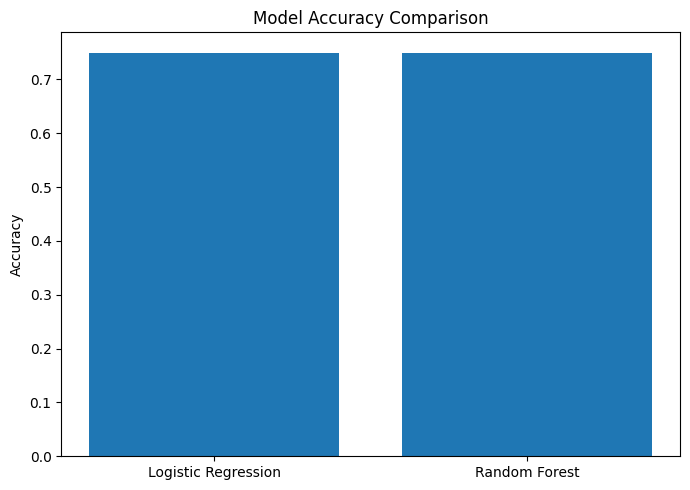

In [17]:
plt.figure(figsize=(7,5))
plt.bar(results_df['Model'],
        results_df['Accuracy'])

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('outputs/figures/rq3_model_accuracy.pdf')
plt.show()